### Inspecting the H5 file

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import sys
from astropy.io import fits


f = h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r')
list(f.keys())

['classes',
 'data',
 'flag_map',
 'freq_range',
 'labels',
 'rfi_corrected',
 'time_range',
 'timestamps']

By seeing the shape of the labels key, we can see that there are only 2854 labels for the entire dataset. Intially, I thought the entire 8K dataset was labelled but turns out only 2854 images have labels. 

Check key in the data

In [4]:
# Open the H5 file in read mode
with h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r') as file:
    print("Keys: %s" % file.keys())
    a_group_key = list(file.keys())[4]  # See the data of [index] key

    # Getting the data
    data = file[a_group_key][:]
    print(data)
    print(f"Shape of key '{a_group_key}': {data.shape}")
    print (f"Data type of key '{a_group_key}': {data.dtype}")

Keys: <KeysViewHDF5 ['classes', 'data', 'flag_map', 'freq_range', 'labels', 'rfi_corrected', 'time_range', 'timestamps']>
[1 1 2 ... 1 3 1]
Shape of key 'labels': (2854,)
Data type of key 'labels': int64


Checka specific date in the data

In [3]:
import h5py

with h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r') as file:
    timestamps = file['timestamps'][:]  # key index 7
    # Decode byte strings and search for the date
    matches = [i for i, ts in enumerate(timestamps) if b'2024-05-14' in ts]
    print(f"Indices with date 2022-07-02: {matches}")
    # Optionally, print the matching timestamps
    for i in matches:
        print(timestamps[i].decode())

Indices with date 2022-07-02: []


In [4]:
dset = f['time_range']
dset.shape

(8147, 2)

Oldest and Latest data entry

In [5]:
import h5py
import re
from datetime import datetime

# Open the H5 file in read mode
with h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r') as file:
    timestamps = file['timestamps'][:]  # Load all timestamps
    
    # Initialize variables to track oldest and latest dates
    oldest_date = None
    latest_date = None
    oldest_index = None
    latest_index = None
    
    # Regular expression to extract date part (YYYY-MM-DD)
    date_pattern = re.compile(r'(\d{4}-\d{2}-\d{2})')
    
    for i, ts in enumerate(timestamps):
        ts_decoded = ts.decode()
        match = date_pattern.search(ts_decoded)
        if match:
            # Extract the date string and convert to datetime object
            date_str = match.group(1)
            date_obj = datetime.strptime(date_str, '%Y-%m-%d')
            
            # Update oldest date if this date is older (or first one)
            if oldest_date is None or date_obj < oldest_date:
                oldest_date = date_obj
                oldest_index = i
                oldest_timestamp = ts_decoded
            
            # Update latest date if this date is newer (or first one)
            if latest_date is None or date_obj > latest_date:
                latest_date = date_obj
                latest_index = i
                latest_timestamp = ts_decoded
    
    # Print results
    print(f"Total timestamps: {len(timestamps)}")
    print(f"Oldest date: {oldest_date.strftime('%Y-%m-%d')} (index {oldest_index})")
    print(f"Oldest timestamp: {oldest_timestamp}")
    print(f"Latest date: {latest_date.strftime('%Y-%m-%d')} (index {latest_index})")
    print(f"Latest timestamp: {latest_timestamp}")
    
    # Calculate the time span
    time_span = latest_date - oldest_date
    print(f"Dataset spans {time_span.days} days ({time_span.days/365.25:.2f} years)")
    
    # Count records per year to see distribution
    year_counts = {}
    for ts in timestamps:
        ts_decoded = ts.decode()
        match = date_pattern.search(ts_decoded)
        if match:
            year = match.group(1)[:4]  # Extract just the year
            year_counts[year] = year_counts.get(year, 0) + 1
    
    print("\nDistribution by year:")
    for year in sorted(year_counts.keys()):
        print(f"  {year}: {year_counts[year]} records")

Total timestamps: 8147
Oldest date: 2022-05-02 (index 56)
Oldest timestamp: 858918_2022-05-02_16:00:00.000000
Latest date: 2023-03-25 (index 8054)
Latest timestamp: 885608_2023-03-25_14:15:00.000000
Dataset spans 327 days (0.90 years)

Distribution by year:
  2022: 7279 records
  2023: 868 records


In [6]:
# Open the H5 file in read mode
with h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r') as file:
    print("Keys: %s" % file.keys())
    a_group_key = list(file.keys())[3] # See the data of [index] key
    
    # Getting the data
    data = list(file[a_group_key])
    print(data)

freqset = f['freq_range']
freqset.shape    

Keys: <KeysViewHDF5 ['classes', 'data', 'flag_map', 'freq_range', 'labels', 'rfi_corrected', 'time_range', 'timestamps']>
[array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([110.49194336, 188.51928711]), array([10.49194336, 88.51928711]), array([10.49194336, 88.51928711]), array([10.49194336, 88.51928711]), array([10.49194336, 88.51928711]), array([10.49194336, 88.51928711]), array([10.49194336, 88.51928711]), array([10.49194336, 88.51928711]), array([10.49194336, 88.51928711]), array([10.49194336, 88.51928711]), array([

(8147, 2)

#### Plot heatmap

In [2]:
# Load HDF5 dataset
with h5py.File('/Volumes/External SSD 512gb/dset_with_labels.h5', 'r') as f:

    labels = f['labels'][:]  # (2854,)
    classes = f['classes'][:]  # (6,)


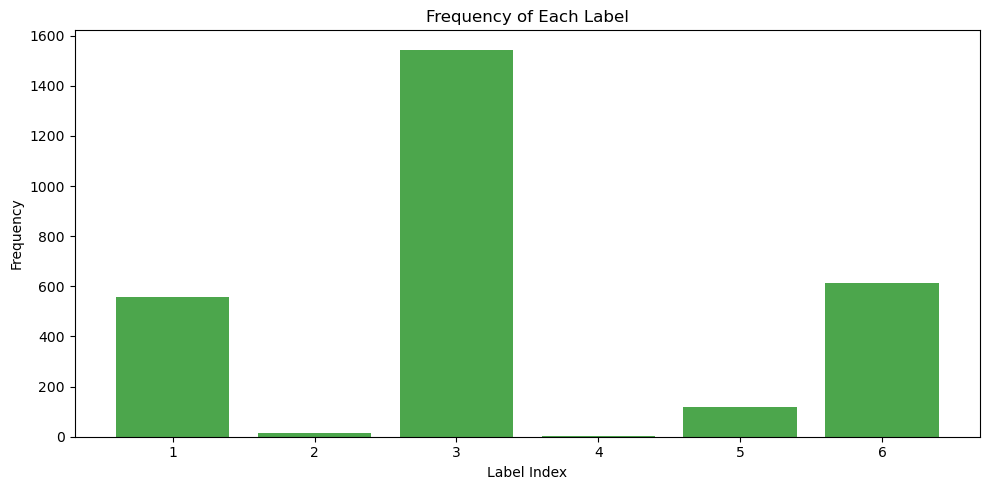

In [ ]:

# Plotting the labels distribution
def plot_labels():
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(labels)), labels, color='blue', alpha=0.7, label='Labels')
    plt.xticks(range(len(labels)), [f'Label {i}' for i in range(len(labels))])
    plt.xlabel('Labels')
    plt.ylabel('Count')
    plt.title('Labels Distribution')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Frequency of label occurrences
def plot_label_frequencies():
    label_counts = Counter(labels)
    sorted_labels = sorted(label_counts.keys())
    frequencies = [label_counts[label] for label in sorted_labels]

    plt.figure(figsize=(10, 5))
    plt.bar(sorted_labels, frequencies, color='green', alpha=0.7)
    plt.xlabel('Label Index')
    plt.ylabel('Frequency')
    plt.title('Frequency of Each Label')
    plt.xticks(sorted_labels)
    plt.tight_layout()
    plt.show()

# Plot label frequencies
plot_label_frequencies()


The number of labels we have is (2854). Now things makes sense from below counts for previous implementation. The data model trained by mattia was size (2723,500,500) since that was only the amount of labels he had. Rest of the data around 5424 image data was not used since lack of labels. 

In [4]:
# Print frequencies of labels 2 and 4
label_counts = Counter(labels)
print(f"Frequency of label 1: {label_counts[1]}")
print(f"Frequency of label 2: {label_counts[2]}")
print(f"Frequency of label 3: {label_counts[3]}")
print(f"Frequency of label 4: {label_counts[4]}")
print(f"Frequency of label 5: {label_counts[5]}")
print(f"Frequency of label 6: {label_counts[6]}")

Frequency of label 1: 559
Frequency of label 2: 14
Frequency of label 3: 1544
Frequency of label 4: 2
Frequency of label 5: 120
Frequency of label 6: 615


### Visualize H5 file data

In [ ]:


from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def sigmoid(x, s, c):
  return 1 / (1 + np.exp(-(x-c)/s))

from tensorflow.image import resize
def download_and_normalize(url):
  imdata = fits.open(url)[0].data
  
  imdata = imdata #/ np.nanmax(imdata)
  normalization = np.mean(
            np.sort(imdata, 0)[
            int(imdata.shape[0] * 0.1):int(imdata.shape[0] * 0.3), :], 0)
  
  normalized = imdata/normalization
  vmin, vmax = np.percentile(normalized, (20, 80))
  #vmax = np.nanmedian(normalized) 
  center = np.mean([vmax, vmin])
  scale = vmax-vmin
  normalized = sigmoid(normalized, scale, center)
  
  normalized = normalized.reshape([*normalized.shape, 1] )
  normalized = resize(normalized, (500, 800)).numpy()
  return normalized[:, :, 0]



Note: you may need to restart the kernel to use updated packages.


/opt/homebrew/Caskroom/miniforge/base/envs/astron/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/astron/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/astron/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tenso

: 

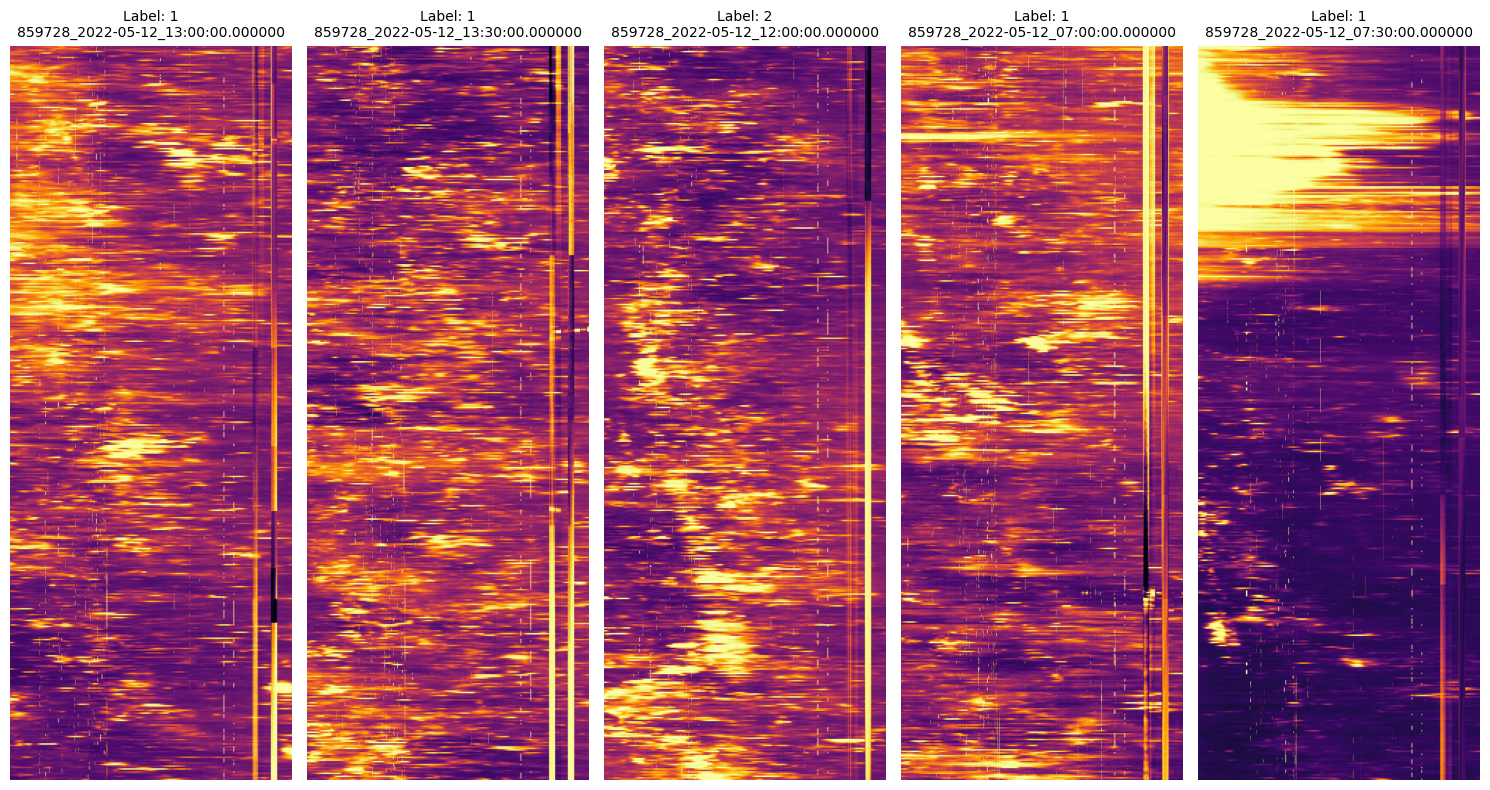

In [12]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from skimage.transform import resize  # Use skimage for resizing

def sigmoid(x, s, c):
    # Use np.clip to avoid overflow in exp
    x = np.clip(x, -1e2, 1e2)
    try:
        return 1 / (1 + np.exp(-(x - c) / (s if s != 0 else 1e-6)))
    except Exception as e:
        print(f"Sigmoid error: {e}")
        return np.zeros_like(x)

def normalize_dynamic_spectrum(imdata):
    try:
        # Defensive: check for NaNs or infs
        if not np.isfinite(imdata).all():
            imdata = np.nan_to_num(imdata)
        # Defensive: check shape
        if imdata.ndim != 2:
            raise ValueError("Input image is not 2D")
        nrows = imdata.shape[0]
        if nrows < 10:
            raise ValueError("Image too small for normalization window")
        norm_slice = np.sort(imdata, 0)[int(nrows * 0.1):int(nrows * 0.3), :]
        normalization = np.mean(norm_slice, 0)
        normalization[normalization == 0] = 1e-6
        normalized = imdata / normalization
        vmin, vmax = np.percentile(normalized, (20, 80))
        center = np.mean([vmax, vmin])
        scale = vmax - vmin if vmax != vmin else 1.0
        normalized = sigmoid(normalized, scale, center)
        normalized = normalized.reshape([*normalized.shape, 1])
        # Use skimage's resize (anti_aliasing for better quality)
        normalized = resize(normalized, (500, 800), anti_aliasing=True, preserve_range=True)
        return normalized[:, :, 0]
    except Exception as e:
        print(f"Normalization error: {e}")
        # Return a blank image if normalization fails
        return np.zeros((500, 800))

h5_path = '/Volumes/External SSD 512gb/dset_with_labels.h5'

try:
    with h5py.File(h5_path, 'r') as f:
        data = f['data'][:2854]      # shape: (2854, H, W)
        labels = f['labels'][:2854]  # shape: (2854,)
        if 'timestamps' in f:
            timestamps = [ts.decode() for ts in f['timestamps'][:2854]]
        else:
            timestamps = [None] * len(labels)
except Exception as e:
    print(f"Failed to load H5 file or datasets: {e}")
    data = np.zeros((5, 500, 800))
    labels = [0]*5
    timestamps = [None]*5

# Plot 5 normalized example images with their labels
num_examples = min(5, len(data))
plt.figure(figsize=(15, 8))
for i in range(num_examples):
    try:
        img = data[i]
        if not np.isfinite(img).all() or np.max(img) == 0 or np.min(img) == np.max(img):
            print(f"Skipping image {i} due to invalid data.")
            continue
        norm_img = normalize_dynamic_spectrum(img)
        plt.subplot(1, num_examples, i+1)
        plt.imshow(norm_img, aspect='auto', cmap='inferno', origin='lower')
        plt.title(f"Label: {labels[i]}\n{timestamps[i] if timestamps[i] else ''}", fontsize=10)
        plt.axis('off')
    except Exception as e:
        print(f"Plotting error for image {i}: {e}")
plt.tight_layout()
plt.show()

View a specific label

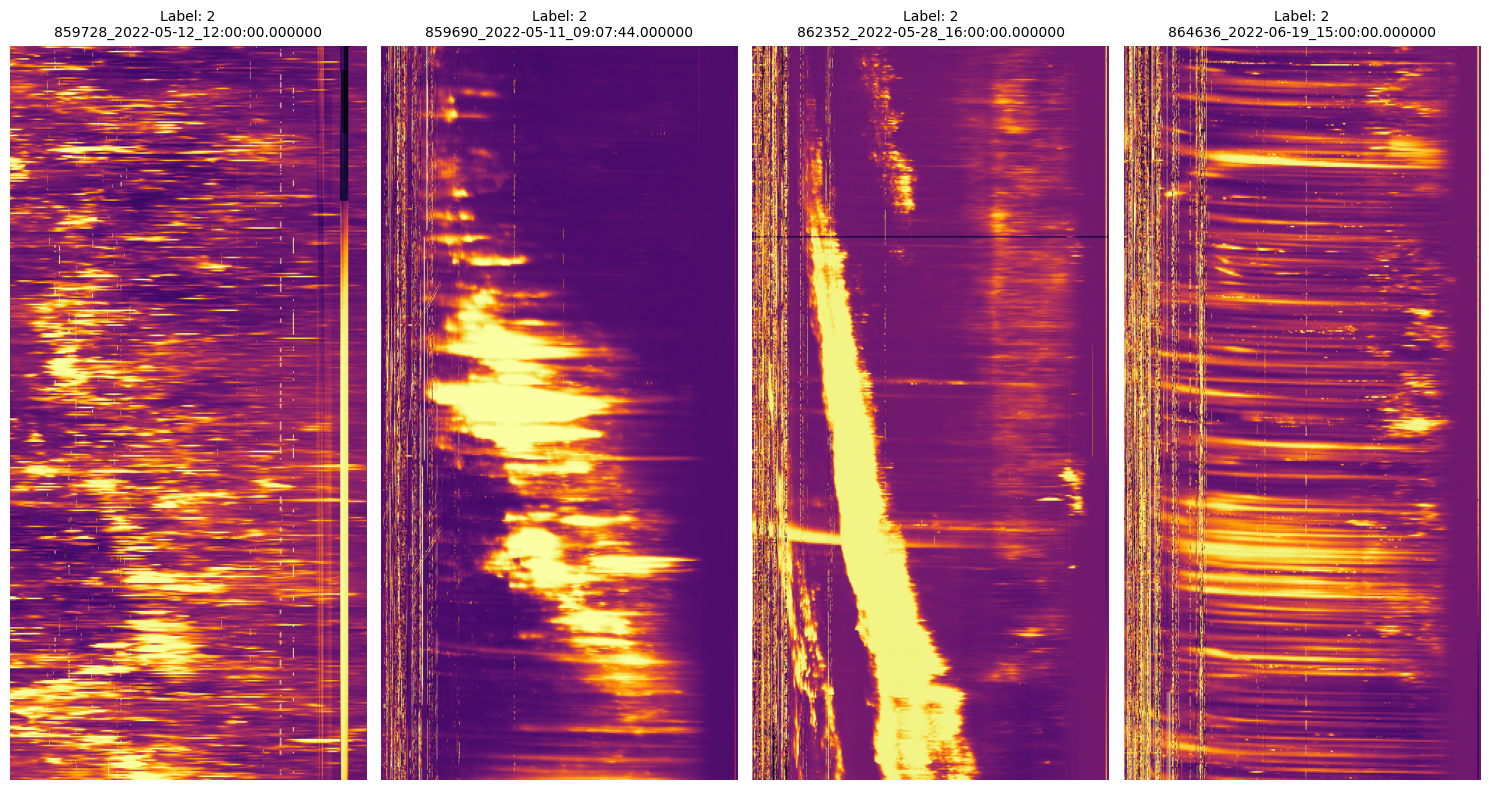

In [21]:
# Show images of only a specific type of label
label_type = 2  # <-- Change this to the label you want to visualize
num_examples = 4

# Find indices where label matches label_type
indices = [i for i, lbl in enumerate(labels) if lbl == label_type]

if not indices:
    print(f"No images found with label {label_type}")
else:
    plt.figure(figsize=(15, 8))
    for plot_idx, i in enumerate(indices[:num_examples]):
        try:
            img = data[i]
            if not np.isfinite(img).all() or np.max(img) == 0 or np.min(img) == np.max(img):
                print(f"Skipping image {i} due to invalid data.")
                continue
            norm_img = normalize_dynamic_spectrum(img)
            plt.subplot(1, min(num_examples, len(indices)), plot_idx+1)
            plt.imshow(norm_img, aspect='auto', cmap='inferno', origin='lower')
            plt.title(f"Label: {labels[i]}\n{timestamps[i] if timestamps[i] else ''}", fontsize=10)
            plt.axis('off')
        except Exception as e:
            print(f"Plotting error for image {i}: {e}")
    plt.tight_layout()
    plt.show()

### The images must be rotated to left once and fliped horizontally to get the right perspective. 

The filter color sceme of the images is done in lightroom. The settings are saved in the app on phone. The eg of the filter that i think is best of ml is in the filtered images folder